In [1]:
import pandas as pd
import numpy as np
raw=pd.read_csv("D:/Crop yield production/Team-Axis/data/raw_data.csv")

In [3]:
raw.head()

,record_id,year,state,district,season,crop_type,sowing_date,seed_variety,area_sown_hectares,irrigation_type,...,soil_ph,nitrogen_kg_ha,phosphorus_kg_ha,potassium_kg_ha,soil_type,soil_moisture_pct,previous_yield_tonnes_ha,yield_trend_pct_yoy,ndvi,yield_tonnes_per_hectare
0,AGRI-00001,2022,Karnataka,Belagavi,Rabi,Maize,2022-11-10,HQPM-1,1.52,Rainfed,...,6.30,80.8,52.4,87.8,Silty Loam,26.8,4.43,3.6,0.703,2.82
1,AGRI-00002,2019,Karnataka,Kalaburagi,Rabi,Maize,2019-11-25,HQPM-1,22.19,Rainfed,...,6.46,156.1,62.5,81.7,Loamy,11.9,5.06,6.4,0.707,2.33
2,AGRI-00003,2019,Punjab,Amritsar,Rabi,Wheat,2019-11-15,HD-2967,8.50,Drip Irrigated,...,7.34,59.5,52.0,28.3,Loamy,47.6,4.37,3.1,0.649,2.31
3,AGRI-00004,2017,Madhya Pradesh,Jabalpur,Rabi,Wheat,2017-10-29,HD-3086,7.48,Irrigated,...,6.83,116.7,60.3,50.1,Loamy,41.3,3.49,8.1,0.575,1.72
4,AGRI-00005,2022,Rajasthan,Bikaner,Kharif,Cotton,2022-06-04,Bunny-Bt,6.44,Rainfed,...,6.76,132.4,25.1,43.1,Alluvial,30.4,2.07,9.3,0.651,1.46


In [5]:
raw.shape

(10000, 26)

In [6]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   record_id                 10000 non-null  str    
 1   year                      10000 non-null  int64  
 2   state                     10000 non-null  str    
 3   district                  10000 non-null  str    
 4   season                    10000 non-null  str    
 5   crop_type                 10000 non-null  str    
 6   sowing_date               10000 non-null  str    
 7   seed_variety              10000 non-null  str    
 8   area_sown_hectares        10000 non-null  float64
 9   irrigation_type           10000 non-null  str    
 10  rainfall_mm               10000 non-null  float64
 11  temperature_min_c         10000 non-null  float64
 12  temperature_max_c         10000 non-null  float64
 13  temperature_avg_c         10000 non-null  float64
 14  humidity_pct      

In [7]:
raw.dtypes

record_id                       str
year                          int64
state                           str
district                        str
season                          str
crop_type                       str
sowing_date                     str
seed_variety                    str
area_sown_hectares          float64
irrigation_type                 str
rainfall_mm                 float64
temperature_min_c           float64
temperature_max_c           float64
temperature_avg_c           float64
humidity_pct                float64
growing_season_days           int64
soil_ph                     float64
nitrogen_kg_ha              float64
phosphorus_kg_ha            float64
potassium_kg_ha             float64
soil_type                       str
soil_moisture_pct           float64
previous_yield_tonnes_ha    float64
yield_trend_pct_yoy         float64
ndvi                        float64
yield_tonnes_per_hectare    float64
dtype: object

In [8]:
raw.isnull().sum()

record_id                   0
year                        0
state                       0
district                    0
season                      0
crop_type                   0
sowing_date                 0
seed_variety                0
area_sown_hectares          0
irrigation_type             0
rainfall_mm                 0
temperature_min_c           0
temperature_max_c           0
temperature_avg_c           0
humidity_pct                0
growing_season_days         0
soil_ph                     0
nitrogen_kg_ha              0
phosphorus_kg_ha            0
potassium_kg_ha             0
soil_type                   0
soil_moisture_pct           0
previous_yield_tonnes_ha    0
yield_trend_pct_yoy         0
ndvi                        0
yield_tonnes_per_hectare    0
dtype: int64

In [9]:
raw.describe()

,year,area_sown_hectares,rainfall_mm,temperature_min_c,temperature_max_c,temperature_avg_c,humidity_pct,growing_season_days,soil_ph,nitrogen_kg_ha,phosphorus_kg_ha,potassium_kg_ha,soil_moisture_pct,previous_yield_tonnes_ha,yield_trend_pct_yoy,ndvi,yield_tonnes_per_hectare
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2021.033600,5.713372,766.833780,18.214990,33.201170,25.447190,63.325300,128.749600,6.668055,105.342360,52.215940,58.192760,35.703270,3.084064,1.916870,0.643631,1.927589
std,2.579794,6.032976,279.911176,3.747481,3.856457,3.519582,12.479477,23.069619,0.627412,34.512157,19.697356,23.465796,9.420328,1.252051,7.004516,0.107087,0.836048
min,2017.000000,0.400000,180.000000,4.000000,17.500000,12.000000,25.000000,90.000000,4.800000,25.000000,8.000000,8.000000,8.000000,0.670000,-20.000000,0.295000,0.250000
25%,2019.000000,1.100000,571.150000,15.700000,30.600000,23.100000,54.500000,112.000000,6.250000,81.900000,38.700000,42.100000,29.300000,2.020000,-2.700000,0.573000,1.260000
50%,2021.000000,3.060000,733.850000,18.300000,33.300000,25.600000,62.700000,124.000000,6.670000,105.400000,52.200000,58.000000,35.900000,2.790000,2.000000,0.644000,1.710000
75%,2023.000000,8.642500,927.825000,20.800000,35.900000,27.900000,71.725000,141.000000,7.090000,129.300000,65.600000,74.200000,42.200000,4.090000,6.700000,0.715000,2.560000
max,2025.000000,24.000000,1800.000000,31.300000,46.500000,38.000000,98.000000,190.000000,8.620000,220.000000,120.100000,143.100000,65.000000,7.170000,24.000000,0.930000,4.890000


In [13]:
import matplotlib.pyplot as plt

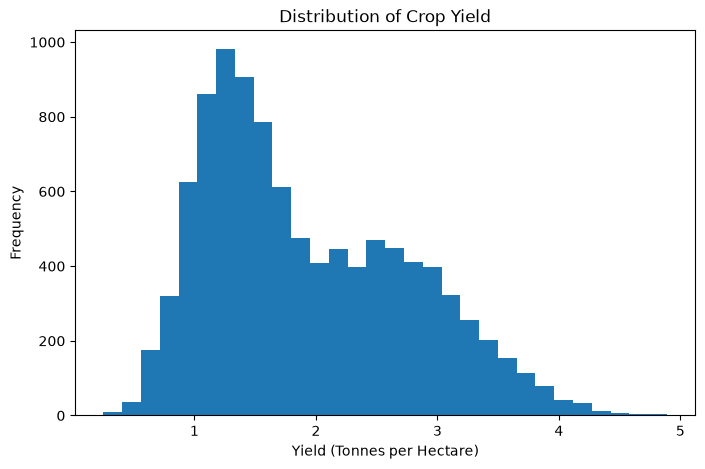

In [14]:
plt.figure(figsize=(8,5))
plt.hist(raw['yield_tonnes_per_hectare'], bins=30)
plt.xlabel('Yield (Tonnes per Hectare)')
plt.ylabel('Frequency')
plt.title('Distribution of Crop Yield')
plt.show()

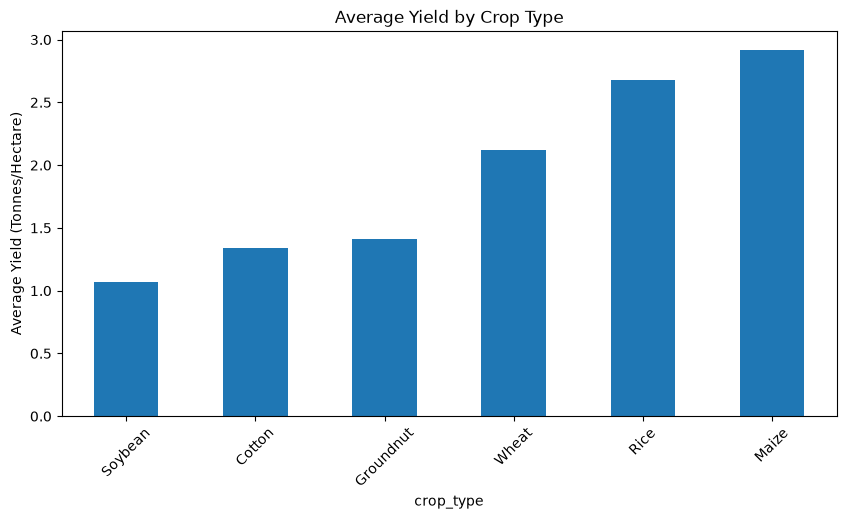

In [16]:
plt.figure(figsize=(10,5))

raw.groupby('crop_type')['yield_tonnes_per_hectare'].mean().sort_values().plot(
    kind='bar'
)

plt.ylabel('Average Yield (Tonnes/Hectare)')
plt.title('Average Yield by Crop Type')
plt.xticks(rotation=45)
plt.show()

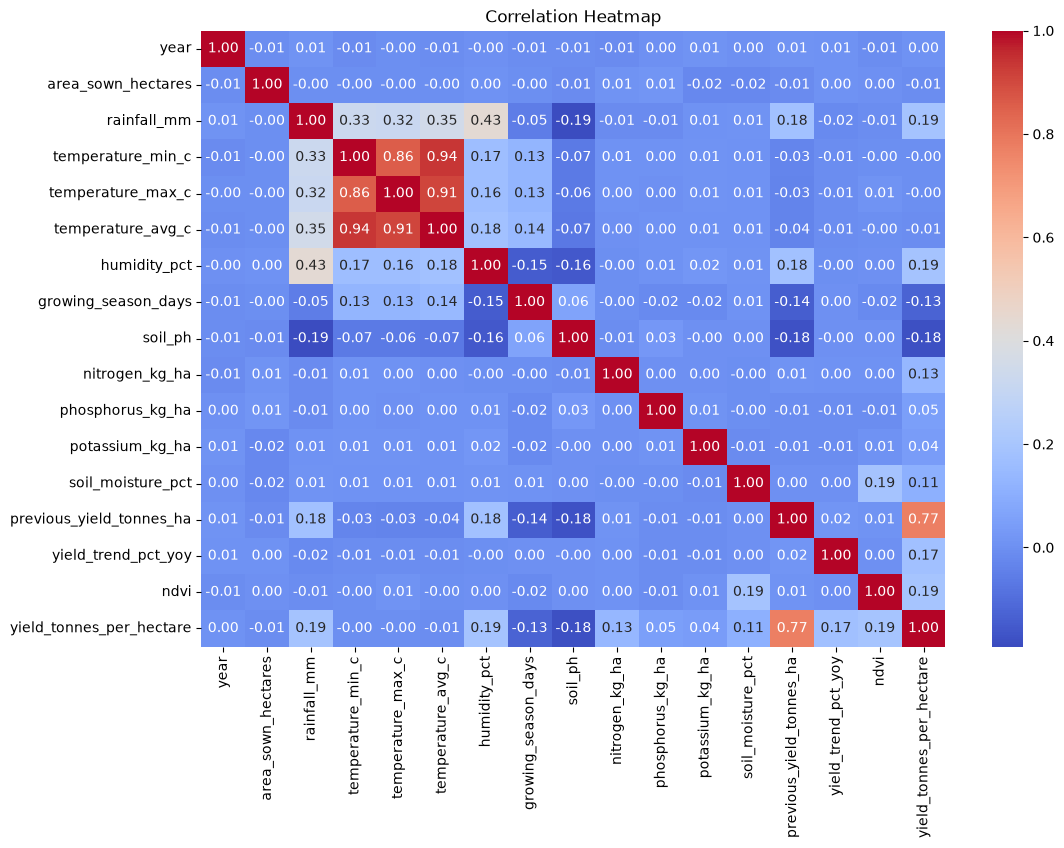

In [18]:
import seaborn as sns

numeric_df = raw.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()